# AI-alapú részvényelemzés

Ebben a notebookban mesterséges intelligencia eszközök segítségével elemzünk egy részvényt – adatletöltéstől a kereskedési stratégiáig.

### Mit fogunk csinálni?
1. Letöltjük a részvény historikus adatait (+ S&P 500 index referenciaként)
2. Megvizsgáljuk az árfolyamot (USD), a napi hozamot és a kumulált hozamot
3. FinBERT modellel elemezzük a részvényhez kapcsolódó híreket
4. Technikai indikátorok alapján kereskedési stratégiát építünk

### Eszközök
- **yfinance** – részvényadatok letöltése
- **pandas, matplotlib** – adatkezelés és vizualizáció
- **FinBERT** – pénzügyi hírek sentiment elemzése
- **Gemini** – kódgenerálás (vibe coding)

> **Vibe coding:** nem mi írjuk a kódot, hanem AI-jal generáltatjuk. Mi pedig értjük, futtatjuk és irányítjuk.

## 1. Telepítés és importok

Az első lépés a szükséges csomagok telepítése és betöltése. Ezt a cellát mindig futtasd le először!

In [2]:
# Csomagok telepítése
!pip install yfinance pandas matplotlib -q

# Importok
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import os
print("Csomagok sikeresen betoltve!")

Csomagok sikeresen betoltve!


## 2. Adatletöltés

Az alábbi cellában beállíthatod a vizsgálni kívánt részvényt és az időszakot.
Az S&P 500 indexet (`^GSPC`) referenciaként mindig letöltjük – összehasonlítási alapként szolgál.

**Paraméterek:**
- `TICKER` – a részvény azonosítója (pl. `AAPL` = Apple, `MSFT` = Microsoft, `TSLA` = Tesla)
- `KEZDO_DATUM` – az elemzés kezdő dátuma (pl. `2020-01-01`)
- `VEGE_DATUM` – az elemzés záró dátuma (pl. `2024-12-31`)

**Adatletöltés logikája:**
1. Ha már van elmentett CSV fájl → azt tölti be
2. Ha nincs → letölti a Yahoo Finance-ről és elmenti
3. Ha a letöltés sem sikerül → betölti a backup adatfájlt

In [3]:
# ============================================================
# PARAMETEREK – itt tudod modositani!
# ============================================================
TICKER      = "AAPL"       # Reszveny ticker szimbóluma
INDEX       = "^GSPC"      # S&P 500 index (referenciaként)
KEZDO_DATUM = "2020-01-01" # Elemzes kezdo datuma (ÉÉÉÉ-HH-NN)
VEGE_DATUM  = "2024-12-31" # Elemzes zaro datuma  (ÉÉÉÉ-HH-NN)
# ============================================================

def lapitas(adat):
    """MultiIndex oszlopokat lapít – yfinance újabb verziókban szükséges."""
    if isinstance(adat.columns, pd.MultiIndex):
        adat.columns = adat.columns.get_level_values(0)
    return adat

def adatot_betolt(ticker, kezdo, vege):
    """Letölti vagy beolvassa a részvény adatait."""
    csv_fajl = f"{ticker.replace('^','')}_adatok.csv"

    # 1. Már feltöltött/mentett CSV
    if os.path.exists(csv_fajl):
        print(f"Mentett adat betöltése: {csv_fajl}")
        adat = pd.read_csv(csv_fajl, index_col=0, parse_dates=True)
        return lapitas(adat)

    # 2. yfinance letöltés
    try:
        print(f"Letöltés: {ticker} ({kezdo} – {vege})...")
        adat = yf.download(ticker, start=kezdo, end=vege, progress=False)
        if adat.empty:
            raise ValueError("Üres adatsor")
        adat = lapitas(adat)
        adat.to_csv(csv_fajl)
        print(f"Letöltve és elmentve: {len(adat)} sor")
        return adat
    except Exception as e:
        print(f"Letöltés sikertelen ({e})")
        print(f"Töltsd fel manuálisan: {csv_fajl}")
        print("Bal oldali fájlkezelő → feltöltés → futtasd újra a cellát")
        return None

# Részvény és index letöltése
df       = adatot_betolt(TICKER, KEZDO_DATUM, VEGE_DATUM)
df_index = adatot_betolt(INDEX,  KEZDO_DATUM, VEGE_DATUM)

# Előnézet
if df is not None:
    print(f"\nRészvény adatok ({TICKER}): {len(df)} sor")
    display(df.tail(3))
if df_index is not None:
    print(f"\nIndex adatok ({INDEX}): {len(df_index)} sor")

Letöltés: AAPL (2020-01-01 – 2024-12-31)...


/tmp/ipykernel_304/281429866.py:29: FutureWarning: YF.download() has changed argument auto_adjust default to True
  adat = yf.download(ticker, start=kezdo, end=vege, progress=False)


Letöltve és elmentve: 1257 sor
Letöltés: ^GSPC (2020-01-01 – 2024-12-31)...


/tmp/ipykernel_304/281429866.py:29: FutureWarning: YF.download() has changed argument auto_adjust default to True
  adat = yf.download(ticker, start=kezdo, end=vege, progress=False)


Letöltve és elmentve: 1257 sor

Részvény adatok (AAPL): 1257 sor


Price,Close,High,Low,Open,Volume
Date,,,,,
2024-12-26,257.612701,258.686851,256.230269,256.787224,27237100
2024-12-27,254.201370,257.294489,251.685117,256.429191,42355300
2024-12-30,250.829803,252.122744,249.387684,250.859639,35557500



Index adatok (^GSPC): 1257 sor


## 3. Árfolyam vizualizáció

Az első vizualizáció: hogyan alakult a részvény záróárfolyama USD-ben az elmúlt években?
A `df` DataFrame `Close` oszlopa tartalmazza a napi záróárakat.

---
**Prompt feladat**

Fogalmazz meg egy promptot a Gemini számára, amely megjeleníti a részvény árfolyamát!

*A kapott kódot másold be az alábbi cellába és futtasd le!*

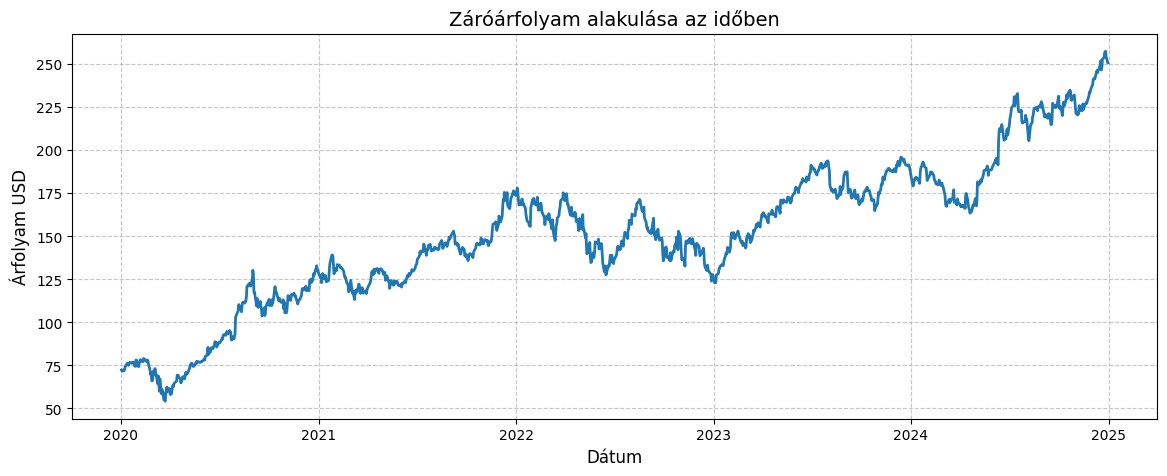

In [4]:
# IDE KERÜL A GEMINI ÁLTAL GENERÁLT KÓD
# Árfolyam vizualizáció – részvény záróára USD-ben

# A grafikon létrehozása a megadott méretben
plt.figure(figsize=(14, 5))

# A 'Close' oszlop kirajzolása
plt.plot(df.index, df['Close'], color='tab:blue', linewidth=2)

# Cím és tengelyfeliratok hozzáadása
plt.title('Záróárfolyam alakulása az időben', fontsize=14)
plt.xlabel('Dátum', fontsize=12)
plt.ylabel('Árfolyam USD', fontsize=12)

# Rácsozás a jobb olvashatóság érdekében (opcionális, de ajánlott)
plt.grid(True, linestyle='--', alpha=0.7)

# Megjelenítés
plt.show()


**Módosító prompt feladat**

Ha megvan az alap diagram, kérd meg a Geminit, hogy jelölje meg a fontos időszakokat:
- COVID-összeomlás: 2020-02 – 2020-06
- Ukrajna háború + kamatemelés: 2022-02 – 2022-12

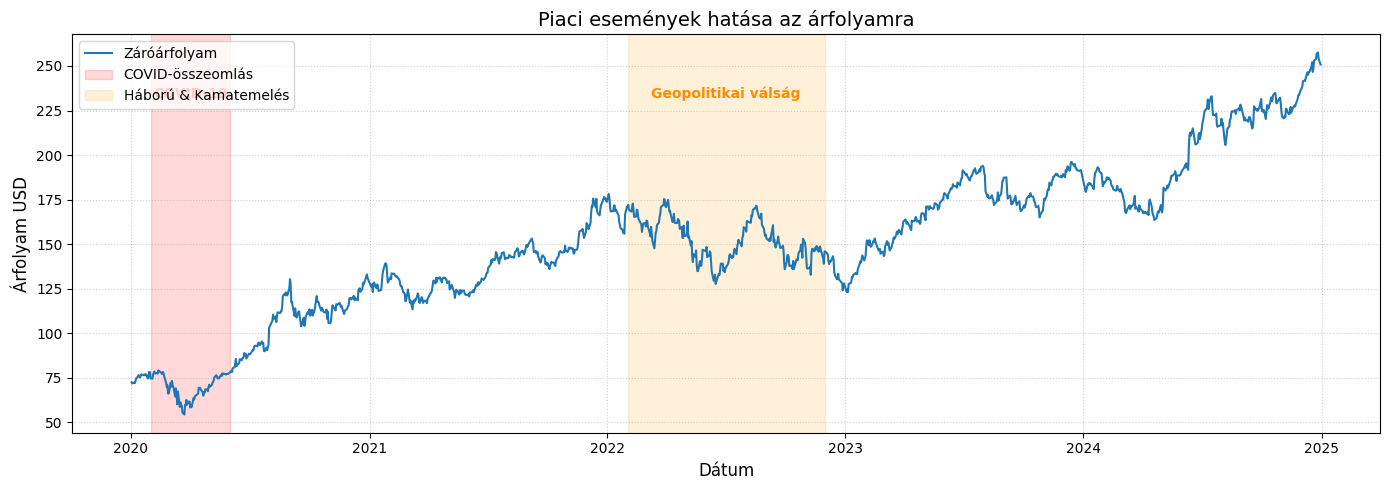

In [5]:
# IDE KERÜL A GEMINI ÁLTAL GENERÁLT KÓD
# Módosítás: krízis időszakok kiemelése

# Biztosítjuk, hogy a dátumok felismerhetőek legyenek a Matplotlib számára
covid_start = pd.to_datetime('2020-02')
covid_end = pd.to_datetime('2020-06')
war_start = pd.to_datetime('2022-02')
war_end = pd.to_datetime('2022-12')

plt.figure(figsize=(14, 5))

# Az alap görbe kirajzolása
plt.plot(df.index, df['Close'], color='#1f77b4', linewidth=1.5, label='Záróárfolyam')

# --- COVID-összeomlás ---
plt.axvspan(covid_start, covid_end, color='red', alpha=0.15, label='COVID-összeomlás')
# A szöveget az időszak közepére pozicionáljuk
plt.text(pd.to_datetime('2020-04-01'), df['Close'].max() * 0.9, 'COVID-19',
         horizontalalignment='center', fontweight='bold', color='red')

# --- Ukrajna háború + kamatemelés ---
plt.axvspan(war_start, war_end, color='orange', alpha=0.15, label='Háború & Kamatemelés')
# A szöveget az időszak közepére pozicionáljuk
plt.text(pd.to_datetime('2022-07-01'), df['Close'].max() * 0.9, 'Geopolitikai válság',
         horizontalalignment='center', fontweight='bold', color='darkorange')

# Formázás
plt.title('Piaci események hatása az árfolyamra', fontsize=14)
plt.xlabel('Dátum', fontsize=12)
plt.ylabel('Árfolyam USD', fontsize=12)
plt.legend(loc='upper left')
plt.grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()


## 4. Napi hozam

A napi hozam (daily return) megmutatja, mekkora volt az árfolyam napi változása százalékban:

$$r_t = \frac{P_t - P_{t-1}}{P_{t-1}} \times 100$$

- Pozitív érték → aznap emelkedett az árfolyam
- Negatív érték → aznap esett
- Nagy kilengések → magas volatilitás, kockázatos időszak

---
**Prompt feladat**

Fogalmazz meg egy promptot a Gemini számára a napi hozam kiszámításához és megjelenítéséhez!
Csak a részvény (`df`) napi hozamát jelenítsd meg.

*A kapott kódot másold be az alábbi cellába és futtasd le!*

---
**Módosító prompt feladat**

Ha megvan az alap diagram, kérd meg a Geminit, hogy emelje ki:
- A legjobb és legrosszabb napot (pont + felirat a dátummal és értékkel)
- Egy vízszintes vonalat a napi hozamok átlagánál

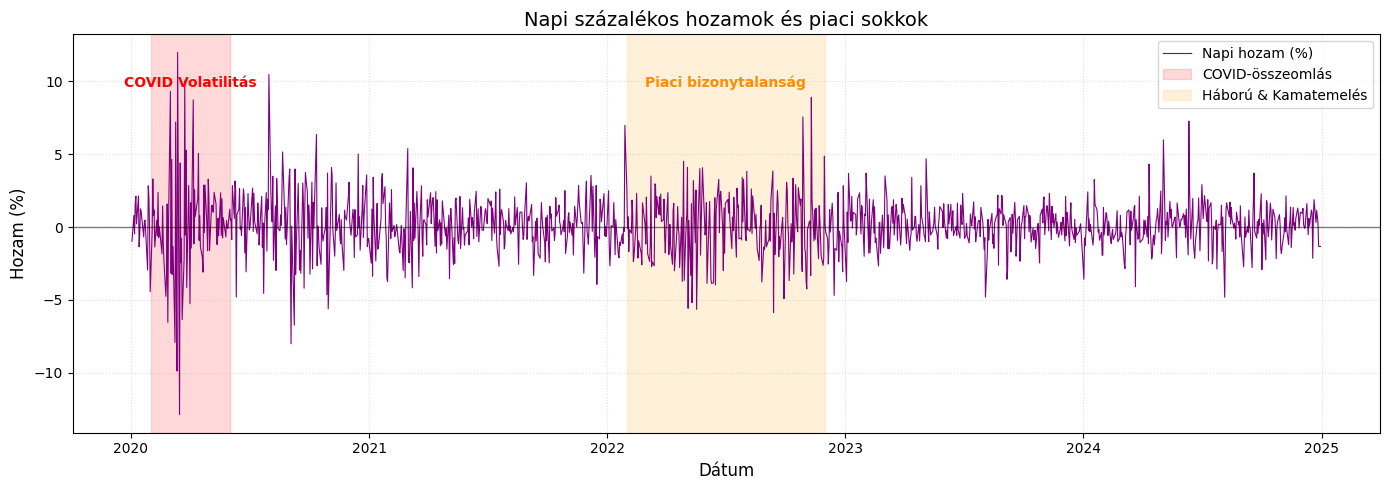

In [ ]:
# IDE KERÜL A GEMINI ÁLTAL GENERÁLT KÓD
# Napi hozam vizualizáció

# 1. Napi százalékos hozam kiszámítása
# A pct_change() az (aktuális/előző - 1) képletet használja
df['Daily_Return'] = df['Close'].pct_change()

# Dátumok definiálása az annotációkhoz
covid_start = pd.to_datetime('2020-02')
covid_end = pd.to_datetime('2020-06')
war_start = pd.to_datetime('2022-02')
war_end = pd.to_datetime('2022-12')

# 2. Diagram létrehozása
plt.figure(figsize=(14, 5))

# A hozamok kirajzolása (százalékos formátum miatt szorozzuk 100-zal)
plt.plot(df.index, df['Daily_Return'] * 100, color='purple', linewidth=0.8, label='Napi hozam (%)')

# Egy vízszintes nullvonal a könnyebb értelmezéshez
plt.axhline(0, color='black', linestyle='-', linewidth=1, alpha=0.5)

# --- Események kiemelése (ugyanaz a stílus) ---
plt.axvspan(covid_start, covid_end, color='red', alpha=0.15, label='COVID-összeomlás')
plt.axvspan(war_start, war_end, color='orange', alpha=0.15, label='Háború & Kamatemelés')

# Feliratok elhelyezése (itt az Y tengely skálája fixebb, pl. -10% és +10% között mozog általában)
y_text_pos = (df['Daily_Return'] * 100).max() * 0.8
plt.text(pd.to_datetime('2020-04-01'), y_text_pos, 'COVID Volatilitás',
         horizontalalignment='center', fontweight='bold', color='red')
plt.text(pd.to_datetime('2022-07-01'), y_text_pos, 'Piaci bizonytalanság',
         horizontalalignment='center', fontweight='bold', color='darkorange')

# Formázás
plt.title('Napi százalékos hozamok és piaci sokkok', fontsize=14)
plt.xlabel('Dátum', fontsize=12)
plt.ylabel('Hozam (%)', fontsize=12)
plt.legend(loc='upper right')
plt.grid(True, linestyle=':', alpha=0.4)

plt.tight_layout()
plt.show()

In [ ]:
# IDE KERÜL A GEMINI ÁLTAL GENERÁLT KÓD
# Módosítás: legjobb/legrosszabb nap + átlagvonal


## 5. Kumulált hozam

A kumulált hozam megmutatja: ha 2020 elején 1000 dollárt fektettél volna be, ma mennyi lenne?
Ezt a részvényre és az S&P 500 indexre egyszerre vizualizáljuk – így látszik, túlteljesítette-e a részvény a piacot.

- A vonal meredeksége → milyen gyorsan nőtt a befektetés értéke
- Ha a részvény vonala az index felett van → a részvény jobban teljesített a piacnál
- Ha alatta → érdemes lett volna inkább indexalapba fektetni

---
**Prompt feladat**

Fogalmazz meg egy promptot a Gemini számára, amely kiszámítja és megjeleníti mindkét eszköz kumulált hozamát!
A `df` a részvény, a `df_index` az S&P 500 adatait tartalmazza.

*A kapott kódot másold be az alábbi cellába és futtasd le!*

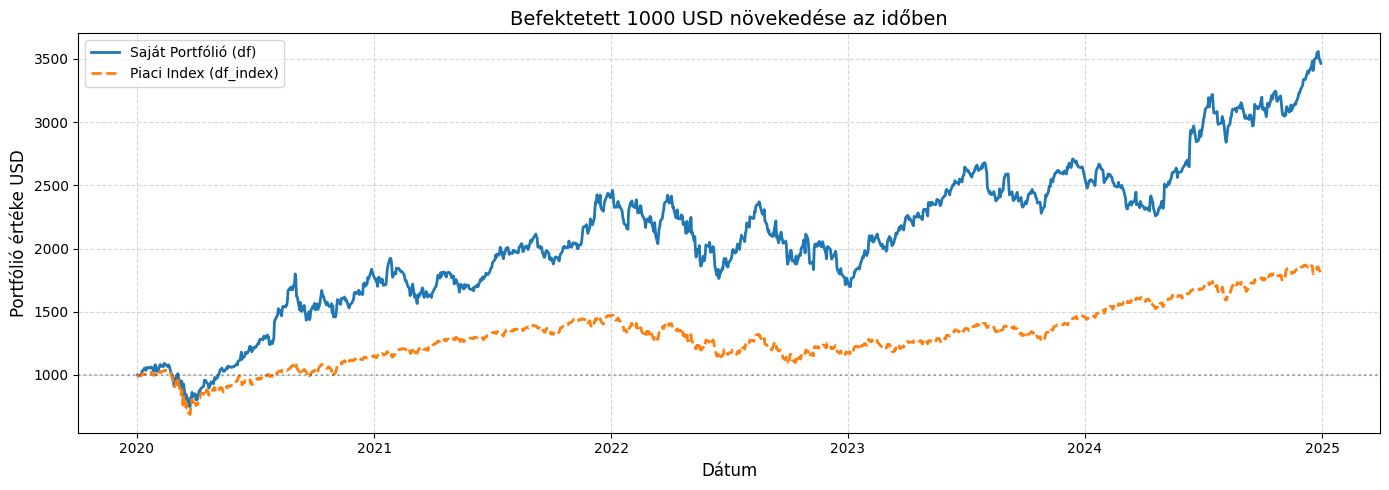

In [ ]:
# IDE KERÜL A GEMINI ÁLTAL GENERÁLT KÓD
# Kumulált hozam – részvény vs. S&P 500

# 1. Beállítások
initial_investment = 1000

# 2. Kumulált érték kiszámítása
# (1 + napi_hozam).cumprod() kiszámítja a növekményt, amit megszorzunk a tőkével
# A fillna(0) biztosítja, hogy az első napon pontosan 1000-ről induljunk
df_value = (1 + df['Close'].pct_change().fillna(0)).cumprod() * initial_investment
index_value = (1 + df_index['Close'].pct_change().fillna(0)).cumprod() * initial_investment

# 3. Diagram létrehozása
plt.figure(figsize=(14, 5))

# Az értékek kirajzolása
plt.plot(df_value.index, df_value, label='AAPL', color='#1f77b4', linewidth=2)
plt.plot(index_value.index, index_value, label='Piaci Index (df_index)', color='#ff7f0e', linestyle='--', linewidth=2)

# Vízszintes vonal a kezdőtőkének (opcionális, de segít a nullszaldó látványában)
plt.axhline(initial_investment, color='black', linestyle=':', alpha=0.3)

# Formázás
plt.title(f'Befektetett {initial_investment} USD növekedése az időben', fontsize=14)
plt.xlabel('Dátum', fontsize=12)
plt.ylabel('Portfólió értéke USD', fontsize=12)
plt.legend(loc='upper left')
plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

---
## 6. FinBERT sentiment elemzés

A **FinBERT** egy pénzügyi szövegekre finomhangolt nyelvi modell – kifejezetten részvénypiaci hírek,
elemzések és jelentések értelmezésére tanították be.
Minden hírhez három értéket ad:

- **positive** – pozitív hangulat valószínűsége
- **negative** – negatív hangulat valószínűsége
- **neutral** – semleges hangulat valószínűsége

A három érték összege mindig 1.

### 6.1 Telepítés és modell betöltése

> **Figyelem:** A FinBERT modell (~400 MB) az első futtatáskor letöltodik a Hugging Face szervereirol.
> Ez 1-2 percet vehet igénybe – ez normális, csak egyszer kell letölteni!

In [ ]:
# FinBERT telepítése
!pip install transformers torch -q

from transformers import BertTokenizer, BertForSequenceClassification
import torch
import pandas as pd

# Modell betöltése – elso futáskor letölti (~400 MB)
print("FinBERT modell betöltése... (elso futáskor 1-2 perc)")
MODEL_NEV = "ProsusAI/finbert"
tokenizer = BertTokenizer.from_pretrained(MODEL_NEV)
model     = BertForSequenceClassification.from_pretrained(MODEL_NEV)
model.eval()
print("Modell betöltve!")

FinBERT modell betöltése... (elso futáskor 1-2 perc)


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:104: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
You are not authenticated with the Hugging Face Hub in this notebook.
If the error persists, please let us know by opening an issue on GitHub (https://github.com/huggingface/huggingface_hub/issues/new).
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/252 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

...

pytorch_model.bin:   0%|          | 0.00/438M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/438M [00:00<?, ?B/s]

BertForSequenceClassification LOAD REPORT from: ProsusAI/finbert
Key                          | Status     |  | 
-----------------------------+------------+--+-
bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Modell betöltve!


### 6.2 Hírek betöltése

Az `AAPL_hirek.csv` fájlt töltsd fel a Colab session-be (bal oldali fájlkezelő → feltöltés).
A fájl 55 ellenőrzött Apple-hírt tartalmaz 2020-2024 közötti időszakból.

In [ ]:
# Hírek betöltése
hirek = pd.read_csv("AAPL_hirek.csv", parse_dates=["date"])
hirek = hirek.sort_values("date").reset_index(drop=True)
print(f"Betöltött hírek: {len(hirek)} db")
print(f"Időszak: {hirek['date'].min().date()} – {hirek['date'].max().date()}")
display(hirek.head())

Betöltött hírek: 55 db
Időszak: 2020-01-28 – 2024-11-14


,date,headline
0,2020-01-28,Apple Reports Record Q1 FY2020 Revenue of $91....
1,2020-02-17,Apple Issues Revenue Warning Withdrawing Q2 Gu...
2,2020-03-13,Apple Closes All Retail Stores Outside Greater...
3,2020-03-13,Apple Announces $15 Million in COVID-19 Donati...
4,2020-04-10,Apple and Google Announce Joint COVID-19 Conta...


### 6.3 Sentiment elemzés futtatása

---
**Prompt feladat**

Fogalmazz meg egy promptot a Gemini számára, amely minden hírhez kiszámítja a FinBERT sentiment score-t!

Kontextus:
- `hirek` egy pandas DataFrame, `date` és `headline` oszlopokkal
- `tokenizer` és `model` már be van töltve
- Az eredményt add hozzá a `hirek` DataFrame-hez: `sentiment` (positive/negative/neutral) és `score` oszlopok

*A kapott kódot másold be az alábbi cellába és futtasd le!*

In [ ]:
# IDE KERÜL A GEMINI ÁLTAL GENERÁLT KÓD
# FinBERT sentiment elemzés – minden hírre

def get_finbert_sentiment(text):
    # Tokenizálás és előrejelzés
    inputs = tokenizer(text, return_tensors="pt", padding=True, truncation=True, max_length=512)

    with torch.no_grad():
        outputs = model(**inputs)
        # Softmax alkalmazása a valószínűségek kinyeréséhez
        probabilities = torch.nn.functional.softmax(outputs.logits, dim=-1).numpy()[0]

    # A modell sorrendje: 0: positive, 1: negative, 2: neutral
    labels = ["positive", "negative", "neutral"]

    # Megkeressük a legmagasabb valószínűségű indexet
    max_idx = np.argmax(probabilities)

    return labels[max_idx], probabilities[max_idx]

# Alkalmazás a DataFrame-re
# Az 'apply' segítségével létrehozunk két új oszlopot
hirek[['sentiment', 'score']] = hirek['headline'].apply(
    lambda x: pd.Series(get_finbert_sentiment(x))
)

# Eredmény ellenőrzése
print(hirek.head())

        date                                           headline sentiment  \
0 2020-01-28  Apple Reports Record Q1 FY2020 Revenue of $91....  positive   
1 2020-02-17  Apple Issues Revenue Warning Withdrawing Q2 Gu...  negative   
2 2020-03-13  Apple Closes All Retail Stores Outside Greater...  negative   
3 2020-03-13  Apple Announces $15 Million in COVID-19 Donati...   neutral   
4 2020-04-10  Apple and Google Announce Joint COVID-19 Conta...   neutral   

      score  
0  0.952466  
1  0.872409  
2  0.956451  
3  0.749913  
4  0.718523  


### 6.4 Eredmények táblázatban

---
**Prompt feladat**

Az előző kód folytatásaként jelenítsd meg az eredményeket egy áttekinthető táblázatban!
Legyen látható a dátum, a hír címe, a sentiment (positive/negative/neutral) és a score.

*A kapott kódot másold be az alábbi cellába és futtasd le!*

In [ ]:
# IDE KERÜL A GEMINI ÁLTAL GENERÁLT KÓD
# Sentiment eredmények táblázatban

def highlight_sentiment(row):
    # Alapértelmezett szín (neutral vagy egyéb)
    color = ''
    if row['sentiment'] == 'positive':
        color = 'background-color: #d4edda; color: #155724' # Halványzöld háttér, sötétzöld szöveg
    elif row['sentiment'] == 'negative':
        color = 'background-color: #f8d7da; color: #721c24' # Halványvörös háttér, sötétvörös szöveg

    return [color] * len(row)

# A táblázat megjelenítése formázva
styled_hirek = hirek[['date', 'headline', 'sentiment', 'score']].style.apply(highlight_sentiment, axis=1)\
    .format({'score': '{:.4f}'}) # A score-t 4 tizedesjegyre kerekítjük a tisztaság kedvéért

styled_hirek

,date,headline,sentiment,score
0,2020-01-28 00:00:00,Apple Reports Record Q1 FY2020 Revenue of $91.8 Billion Up 9% Year-Over-Year,positive,0.9525
1,2020-02-17 00:00:00,Apple Issues Revenue Warning Withdrawing Q2 Guidance Due to COVID-19 Impact,negative,0.8724
2,2020-03-13 00:00:00,Apple Closes All Retail Stores Outside Greater China Due to COVID-19,negative,0.9565
3,2020-03-13 00:00:00,Apple Announces $15 Million in COVID-19 Donations and 2:1 Employee Matching,neutral,0.7499
4,2020-04-10 00:00:00,Apple and Google Announce Joint COVID-19 Contact Tracing Technology Partnership,neutral,0.7185
5,2020-04-30 00:00:00,Apple Reports Q2 FY2020 Revenue of $58.3 Billion and Adds $50B to Buyback Program,neutral,0.6420
6,2020-06-22 00:00:00,Apple Announces Transition from Intel to Apple Silicon for Mac at WWDC 2020,neutral,0.8750
7,2020-07-30 00:00:00,Apple Reports Q3 FY2020 Revenue of $59.7 Billion and Announces 4-for-1 Stock Split,neutral,0.9197
8,2020-08-19 00:00:00,Apple Becomes First U.S. Company to Reach $2 Trillion Market Capitalization,positive,0.5985
9,2020-10-13 00:00:00,Apple Unveils iPhone 12 Lineup with 5G Support at Hi Speed Virtual Event,neutral,0.8094


### 6.5 Top 5 legpozitívabb és legnegatívabb hír

Melyik hír kapta a legmagasabb pozitív score-t? Melyik a legnegatívabbat?

---
**Prompt feladat**

Az előző kód folytatásaként jelenítsd meg a top 5 legpozitívabb és
top 5 legnegatívabb hírt két külön táblázatban, score szerint rendezve!

*A kapott kódot másold be az alábbi cellába és futtasd le!*

In [ ]:
# IDE KERÜL A GEMINI ÁLTAL GENERÁLT KÓD
# Top 5 legpozitívabb és legnegatívabb hír

# Top 5 legpozitívabb hír (score szerint csökkenő)
top_positive = hirek[hirek['sentiment'] == 'positive']\
    .sort_values(by='score', ascending=False)\
    .head(5)

# Top 5 legnegatívabb hír (score szerint csökkenő)
top_negative = hirek[hirek['sentiment'] == 'negative']\
    .sort_values(by='score', ascending=False)\
    .head(5)

# Megjelenítés stílusozással
print("--- TOP 5 LEGPOZITÍVABB HÍR ---")
display(top_positive.style.set_properties(**{'background-color': '#d4edda', 'color': '#155724'})\
        .format({'score': '{:.4f}'}))

print("\n--- TOP 5 LEGNEGATÍVABB HÍR ---")
display(top_negative.style.set_properties(**{'background-color': '#f8d7da', 'color': '#721c24'})\
        .format({'score': '{:.4f}'}))


--- TOP 5 LEGPOZITÍVABB HÍR ---


,date,headline,sentiment,score
21,2021-10-28 00:00:00,Apple Reports Q4 FY2021 Revenue of $83.4 Billion Up 29% Year-Over-Year,positive,0.9541
15,2021-04-28 00:00:00,Apple Reports Q2 FY2021 Revenue of $89.6 Billion Up 54% Year-Over-Year,positive,0.9538
28,2022-07-28 00:00:00,Apple Reports Q3 FY2022 Revenue of $83.0 Billion Up 2% Year-Over-Year,positive,0.9535
17,2021-07-27 00:00:00,Apple Reports Q3 FY2021 Revenue of $81.4 Billion Up 36% Year-Over-Year,positive,0.9535
49,2024-08-01 00:00:00,Apple Reports Q3 FY2024 Revenue of $85.8 Billion Up 5% Year-Over-Year,positive,0.9534



--- TOP 5 LEGNEGATÍVABB HÍR ---


,date,headline,sentiment,score
33,2023-02-02 00:00:00,Apple Reports Q1 FY2023 Revenue of $117.2 Billion Down 5% Year-Over-Year,negative,0.9752
31,2022-11-06 00:00:00,Apple Warns COVID Restrictions at Foxconn Zhengzhou Will Significantly Reduce iPhone 14 Pro Shipments,negative,0.9645
50,2024-08-03 00:00:00,Berkshire Hathaway Slashes Apple Stake by Nearly 50% in Q2 2024 Cash Hits Record $277B,negative,0.9639
2,2020-03-13 00:00:00,Apple Closes All Retail Stores Outside Greater China Due to COVID-19,negative,0.9565
54,2024-11-14 00:00:00,Berkshire Hathaway Q3 2024 13F Shows Apple Stake Reduced to About 300 Million Shares,negative,0.9503


### 6.6 Sentiment megoszlás

Összességében hogyan oszlanak meg a hírek?

---
**Prompt feladat**

Az előző kód folytatásaként készíts kördiagramot a sentiment kategóriák megoszlásáról!

*A kapott kódot másold be az alábbi cellába és futtasd le!*

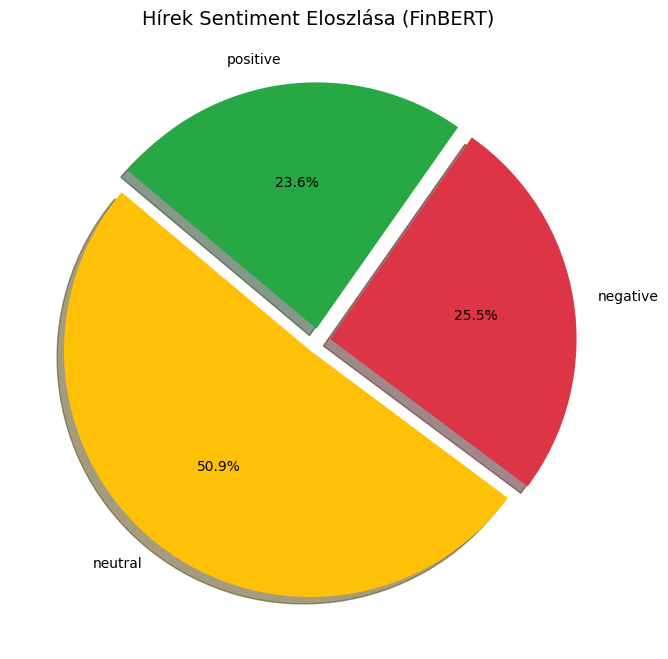

In [ ]:
# IDE KERÜL A GEMINI ÁLTAL GENERÁLT KÓD
# Sentiment megoszlás kördiagram

# Adatok előkészítése: megszámoljuk az egyes kategóriákat
sentiment_counts = hirek['sentiment'].value_counts()

# Színpaletta definiálása (összhangban a korábbi táblázattal)
colors_map = {
    'positive': '#28a745', # Zöld
    'negative': '#dc3545', # Piros
    'neutral': '#ffc107'   # Sárga/Arany
}

# Biztosítjuk, hogy a színek a megfelelő kategóriához tartozzanak
colors = [colors_map.get(x, '#6c757d') for x in sentiment_counts.index]

# Diagram létrehozása
plt.figure(figsize=(8, 8))
plt.pie(
    sentiment_counts,
    labels=sentiment_counts.index,
    autopct='%1.1f%%',
    startangle=140,
    colors=colors,
    explode=[0.05] * len(sentiment_counts), # Kicsit "szétrobbantjuk" a szeleteket a jobb láthatóságért
    shadow=True
)

plt.title('Hírek sentiment eloszlása (FinBERT)', fontsize=14)
plt.show()

### 6.7 Hírek az árfolyamon

Az utolsó vizualizáció: minden hír megjelenik az árfolyam diagramon egy pontként –
zölddel a pozitív, pirossal a negatív híreket jelölve.

> **Megjegyzés:** 55 hírből statisztikai korrelációt számolni nem lenne megbízható.
> Amit viszont látunk: a FinBERT helyesen azonosítja a negatív és pozitív híreket –
> ez önmagában is értékes eredmény. Megbízható korreláció számításhoz
> több száz hír kellene egyenletes időbeli elosztással.

---
**Prompt feladat**

Az előző kód folytatásaként jelenítsd meg az AAPL árfolyamát (`df`),
és rajzold rá a híreket pontként: zöld = pozitív, piros = negatív, szürke = semleges.
Legyen jelmagyarázat és cím.

*A kapott kódot másold be az alábbi cellába és futtasd le!*

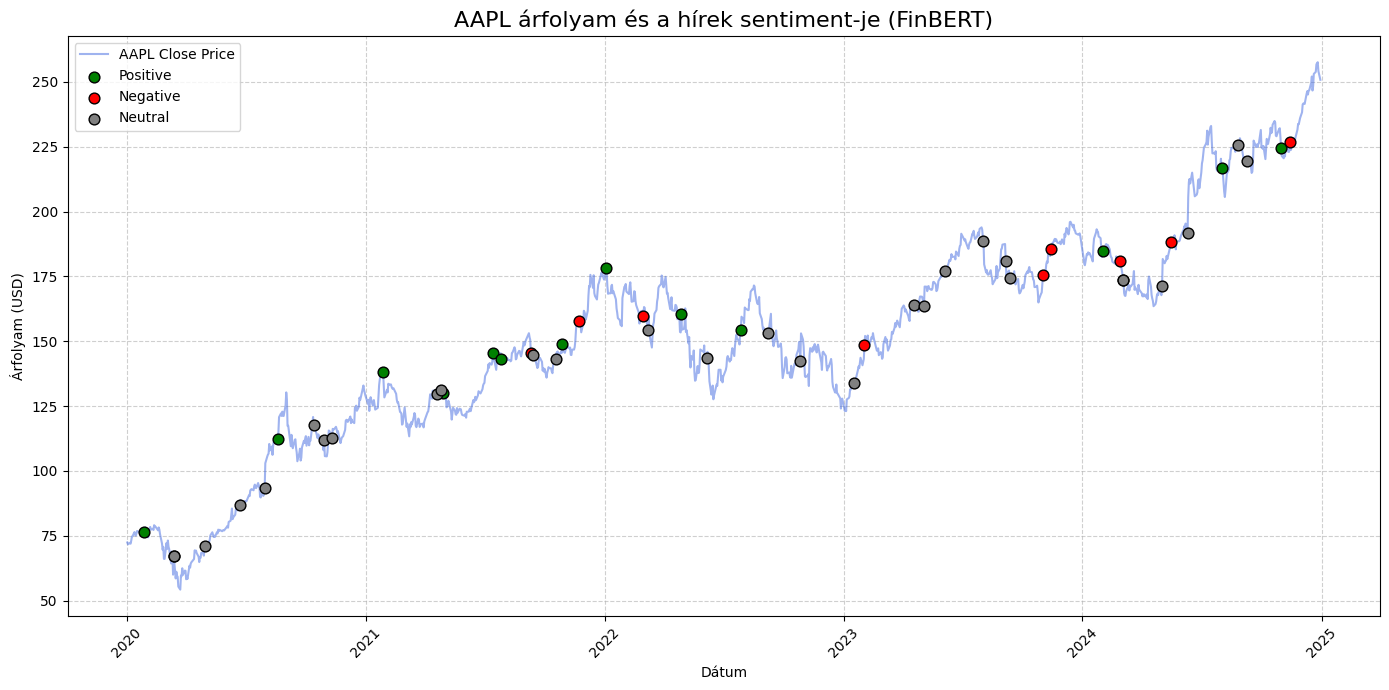

In [ ]:
# IDE KERÜL A GEMINI ÁLTAL GENERÁLT KÓD
# Árfolyam + hírek scatter plot (zöld=pozitív, piros=negatív, szürke=semleges)

import matplotlib.pyplot as plt

# 1. Előkészítés: Biztosítjuk a dátum formátumot és az indexelést
df.index = pd.to_datetime(df.index)
hirek['date'] = pd.to_datetime(hirek['date'])

# 2. Összefésüljük a híreket az árfolyammal a dátum mentén
# Megkeressük az adott napi záróárat minden hírhez
hirek_with_price = hirek.merge(df[['Close']], left_on='date', right_index=True, how='left')

# 3. Diagram létrehozása
plt.figure(figsize=(14, 7))

# Árfolyam görbe (folytonos vonal)
plt.plot(df.index, df['Close'], label='AAPL Close Price', color='royalblue', alpha=0.5, linewidth=1.5)

# Sentiment pontok rávetítése
sentiment_colors = {'positive': 'green', 'negative': 'red', 'neutral': 'gray'}

for sentiment, color in sentiment_colors.items():
    subset = hirek_with_price[hirek_with_price['sentiment'] == sentiment]
    plt.scatter(subset['date'], subset['Close'],
                label=sentiment.capitalize(),
                color=color,
                s=60,           # Pont mérete
                edgecolor='black',
                zorder=3)       # Hogy a vonal felett legyen

# Formázás
plt.title('AAPL árfolyam és a hírek sentiment-je (FinBERT)', fontsize=16)
plt.xlabel('Dátum')
plt.ylabel('Árfolyam (USD)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

---
## 7. Kereskedési stratégia

Az eddig látott árfolyam és sentiment adatok alapján most egy egyszerű
**kereskedési stratégiát** építünk – mozgóátlagok alapján.

Az ötlet egyszerű: ha a rövid távú átlag átlép a hosszú távú átlag fölé,
az emelkedő trendet jelzi → vásárlási jel. Ha alá kerül → eladási jel.

Ezt a két keresztezési pontot hívják:
- **Golden cross** – rövid átlag átlép a hosszú fölé → vétel
- **Death cross** – rövid átlag átlép a hosszú alá → eladás

### 7.1 Technikai indikátorok (előre megírva)

Kiszámítjuk az 50 és 200 napos mozgóátlagot, és megjelenítjük az árfolyamon.

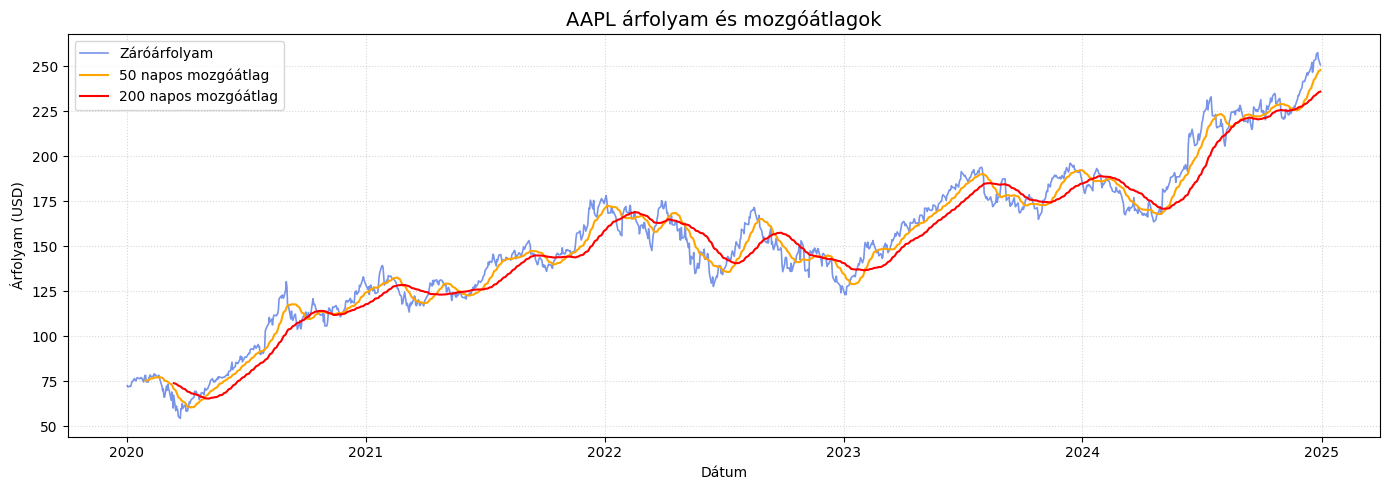

Mozgóátlagok kiszámítva: MA50 és MA200 hozzáadva a df-hez


In [ ]:
# Mozgóátlagok kiszámítása
df['MA50']  = df['Close'].rolling(window=20).mean()
df['MA200'] = df['Close'].rolling(window=50).mean()

# Vizualizáció
plt.figure(figsize=(14, 5))
plt.plot(df.index, df['Close'], label='Záróárfolyam', color='royalblue', linewidth=1.2, alpha=0.7)
plt.plot(df.index, df['MA50'],  label='50 napos mozgóátlag', color='orange', linewidth=1.5)
plt.plot(df.index, df['MA200'], label='200 napos mozgóátlag', color='red',    linewidth=1.5)
plt.title('AAPL árfolyam és mozgóátlagok', fontsize=14)
plt.xlabel('Dátum')
plt.ylabel('Árfolyam (USD)')
plt.legend()
plt.grid(True, linestyle=':', alpha=0.5)
plt.tight_layout()
plt.show()
print('Mozgóátlagok kiszámítva: MA50 és MA200 hozzáadva a df-hez')

### 7.2 Kereskedési jelzések generálása

Most meghatározzuk a vételi és eladási jelzések pontjait:
- **Golden cross:** az MA50 átlép az MA200 fölé → vétel
- **Death cross:** az MA50 átlép az MA200 alá → eladás

---
**Prompt feladat**

Fogalmazz meg egy promptot a Gemini számára, amely meghatározza
a vételi és eladási jelzések pontjait, és megjeleníti őket az árfolyamon!

Kontextus:
- `df` DataFrame tartalmazza a `Close`, `MA50`, `MA200` oszlopokat
- Golden cross: MA50 átlép MA200 fölé → zöld háromszög jelölje
- Death cross: MA50 átlép MA200 alá → piros háromszög jelölje

*A kapott kódot másold be az alábbi cellába és futtasd le!*

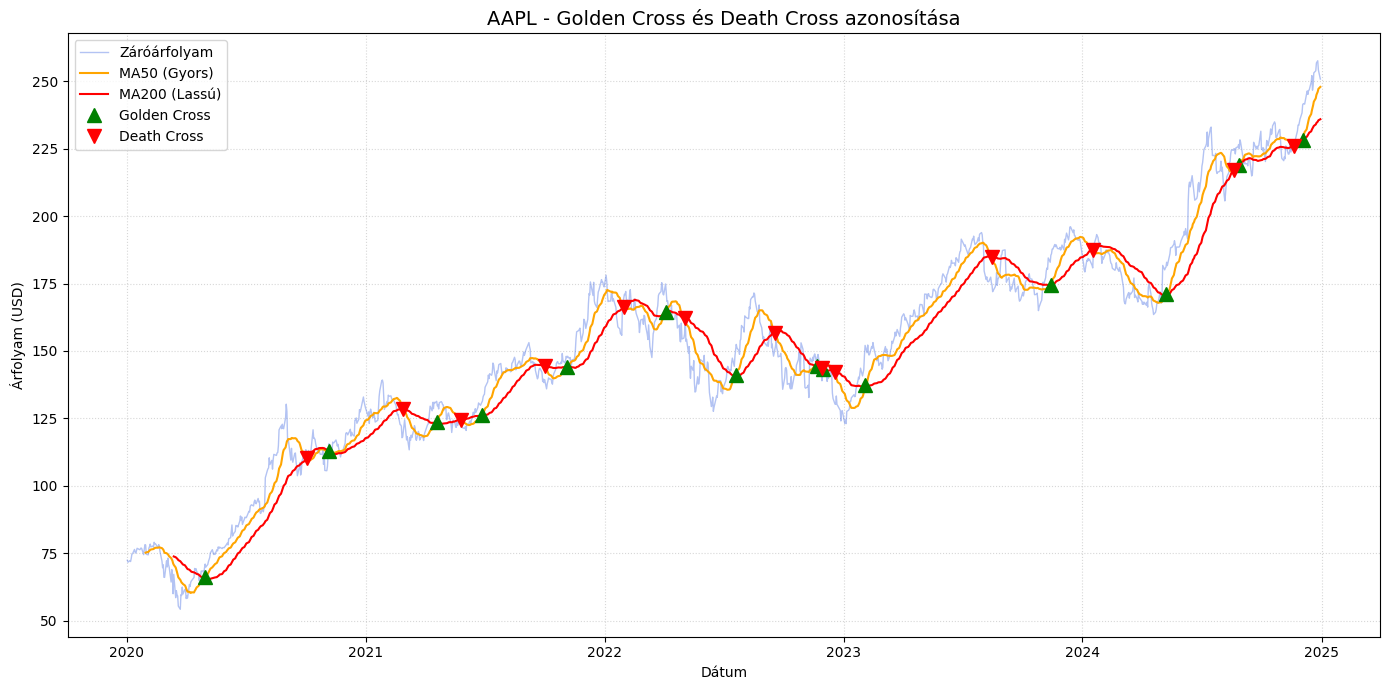

Aranykeresztek száma: 14
Halálkeresztek száma: 13


In [ ]:
# IDE KERÜL A GEMINI ÁLTAL GENERÁLT KÓD
# Kereskedési jelzések – golden cross és death cross

# 1. Szignálok generálása
# 'Signal' oszlop: 1 ha MA50 > MA200, egyébként 0
df['Signal'] = np.where(df['MA50'] > df['MA200'], 1, 0)

# 'Position' oszlop: a Signal különbsége (1: Golden Cross, -1: Death Cross)
df['Position'] = df['Signal'].diff()

# 2. Vizualizáció bővítése
plt.figure(figsize=(14, 7))

# Árfolyam és mozgóátlagok
plt.plot(df.index, df['Close'], label='Záróárfolyam', color='royalblue', alpha=0.4, linewidth=1)
plt.plot(df.index, df['MA50'],  label='MA50 (Gyors)', color='orange', linewidth=1.5)
plt.plot(df.index, df['MA200'], label='MA200 (Lassú)', color='red', linewidth=1.5)

# Golden Cross jelzése (vétel)
plt.plot(df[df['Position'] == 1].index,
         df['MA50'][df['Position'] == 1],
         '^', markersize=10, color='g', label='Golden Cross', lw=0)

# Death Cross jelzése (eladás)
plt.plot(df[df['Position'] == -1].index,
         df['MA200'][df['Position'] == -1],
         'v', markersize=10, color='r', label='Death Cross', lw=0)

plt.title('AAPL - Golden Cross és Death Cross azonosítása', fontsize=14)
plt.xlabel('Dátum')
plt.ylabel('Árfolyam (USD)')
plt.legend(loc='best')
plt.grid(True, linestyle=':', alpha=0.5)
plt.tight_layout()
plt.show()

# Eredmények összegzése a konzolon
print(f"Aranykeresztek száma: {len(df[df['Position'] == 1])}")
print(f"Halálkeresztek száma: {len(df[df['Position'] == -1])}")

### 7.3 Backtesting – hogyan teljesített a stratégia?

Ha 2020 elején 1000 dollárral indultunk és minden jelzésnél vettünk/eladtunk,
mennyit ér most a portfóliónk? Megverte-e a stratégia az egyszerű buy & hold megközelítést?

---
**Prompt feladat**

Az előző kód folytatásaként szimulálj egy egyszerű backtestet!
1000 dolláros kezdőtőkével, minden golden cross-nál vétel, minden death cross-nál eladás.
Számítsd ki a végső portfólió értékét.

*A kapott kódot másold be az alábbi cellába és futtasd le!*

In [ ]:
# ====================== SMA CROSSOVER STRATÉGIA – LOGIKAILAG HELYES VERZIÓ ======================

initial_capital = 1000.0
cash = initial_capital
shares = 0.0
portfolio_value = []

for i in range(len(df)):
    current_price = df['Close'].iloc[i]

    # Aktuális állapot: long pozícióban vagyunk-e?
    in_market = df['Signal'].iloc[i] == 1          # Signal = 1, ha SMA50 > SMA200

    # Vétel (Golden Cross)
    if in_market and shares == 0:
        shares = cash / current_price
        cash = 0
        print(f"VÉTEL  | {df.index[i].date()} | Ár: {current_price:.2f} | Részvény: {shares:.4f}")

    # Eladás (Death Cross)
    elif not in_market and shares > 0:
        cash = shares * current_price
        shares = 0
        print(f"ELADÁS | {df.index[i].date()} | Ár: {current_price:.2f} | Tőke: {cash:.2f} USD")

    # Portfólió aktuális értéke
    total_value = cash + (shares * current_price)
    portfolio_value.append(total_value)

df['Total_Value'] = portfolio_value

# Végeredmény
final_value = df['Total_Value'].iloc[-1]
profit_pct = ((final_value - initial_capital) / initial_capital) * 100

print("\n" + "="*60)
print(f"Kezdőtőke:          {initial_capital:.2f} USD")
print(f"Végső portfólió:    {final_value:.2f} USD")
print(f"Összesített hozam:  {profit_pct:.2f}%")
print("="*60)

VÉTEL  | 2020-04-30 | Ár: 70.99 | Részvény: 14.0866
ELADÁS | 2020-10-02 | Ár: 109.73 | Tőke: 1545.68 USD
VÉTEL  | 2020-11-05 | Ár: 115.56 | Részvény: 13.3753
ELADÁS | 2021-02-26 | Ár: 118.11 | Tőke: 1579.71 USD
VÉTEL  | 2021-04-19 | Ár: 131.33 | Részvény: 12.0282
ELADÁS | 2021-05-26 | Ár: 123.76 | Tőke: 1488.63 USD
VÉTEL  | 2021-06-28 | Ár: 131.50 | Részvény: 11.3205
ELADÁS | 2021-10-01 | Ár: 139.38 | Tőke: 1577.91 USD
VÉTEL  | 2021-11-04 | Ár: 147.50 | Részvény: 10.6974
ELADÁS | 2022-01-31 | Ár: 171.03 | Tőke: 1829.56 USD
VÉTEL  | 2022-04-05 | Ár: 171.52 | Részvény: 10.6667
ELADÁS | 2022-05-03 | Ár: 156.26 | Tőke: 1666.73 USD
VÉTEL  | 2022-07-20 | Ár: 150.17 | Részvény: 11.0992
ELADÁS | 2022-09-19 | Ár: 151.79 | Tőke: 1684.75 USD
VÉTEL  | 2022-11-21 | Ár: 145.67 | Részvény: 11.5652
ELADÁS | 2022-11-29 | Ár: 138.94 | Tőke: 1606.90 USD
VÉTEL  | 2022-12-01 | Ár: 145.97 | Részvény: 11.0085
ELADÁS | 2022-12-19 | Ár: 130.28 | Tőke: 1434.19 USD
VÉTEL  | 2023-02-03 | Ár: 152.06 | Részvény: 9.

### 7.4 Stratégia vs. Buy & Hold

Az utolsó vizualizáció: hogyan alakult a portfólió értéke időben –
a mozgóátlag stratégiával és az egyszerű buy & hold megközelítéssel összehasonlítva.

---
**Prompt feladat**

Az előző kód folytatásaként jelenítsd meg egy diagramon a mozgóátlag stratégia
és a buy & hold portfólió értékét időben, 1000 dolláros kezdőtőkéről indulva.
Legyen cím, tengelyfeliratok és jelmagyarázat.

*A kapott kódot másold be az alábbi cellába és futtasd le!*

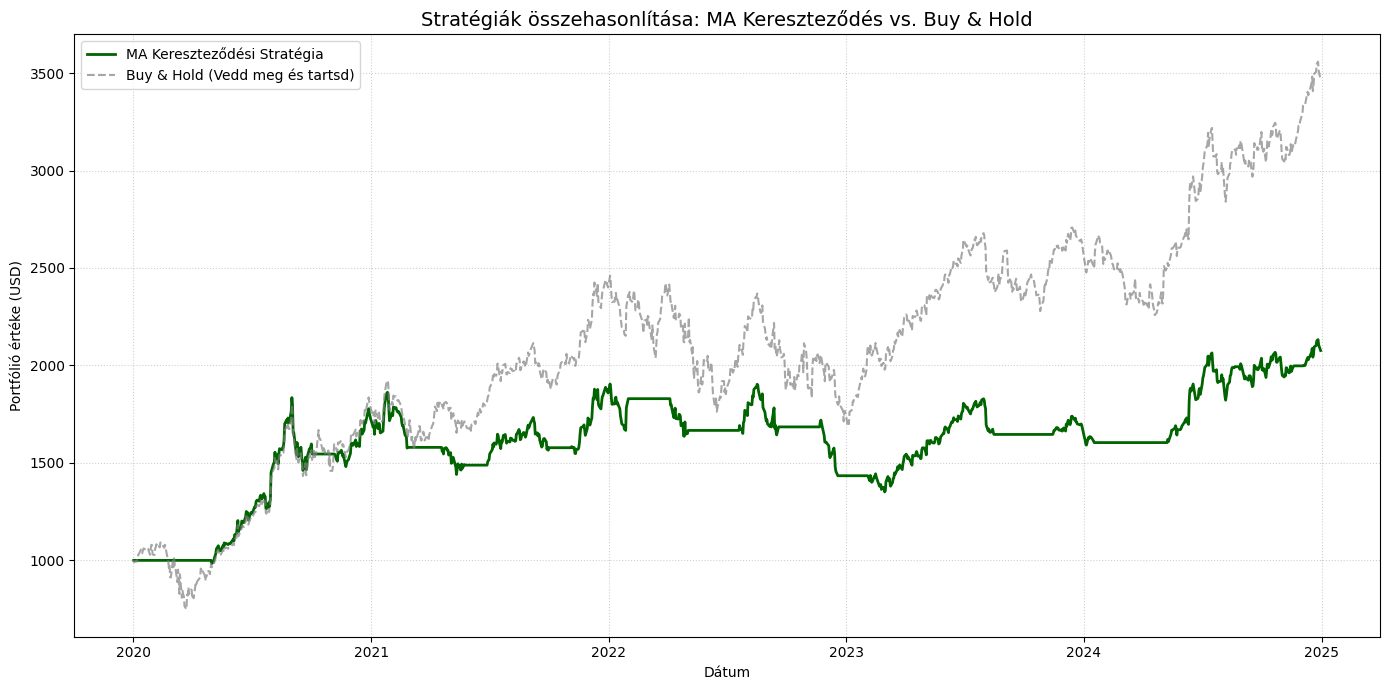

MA Stratégia végső értéke:  2076.52 USD
Buy & Hold végső értéke:    3464.47 USD
Különbség:                  -1387.96 USD


In [ ]:
# IDE KERÜL A GEMINI ÁLTAL GENERÁLT KÓD
# Stratégia vs. Buy & Hold összehasonlítás

# 1. Buy & Hold stratégia kiszámítása
# Az első elérhető záróáron megvesszük a részvényeket a 1000 dollárból
initial_price = df['Close'].iloc[0]
shares_bh = initial_capital / initial_price
df['Buy_Hold_Value'] = df['Close'] * shares_bh

# 2. Vizualizáció: Equity Curve (Tőke-görbe)
plt.figure(figsize=(14, 7))

# Mozgóátlag stratégia tőkéje (az előző lépésben kiszámolt Total_Value)
plt.plot(df.index, df['Total_Value'], label='MA Kereszteződési Stratégia', color='darkgreen', linewidth=2)

# Buy & Hold stratégia tőkéje
plt.plot(df.index, df['Buy_Hold_Value'], label='Buy & Hold (Vedd meg és tartsd)', color='gray', linestyle='--', alpha=0.7)

# Grafikon szépítése
plt.title('Stratégiák összehasonlítása: MA Kereszteződés vs. Buy & Hold', fontsize=14)
plt.xlabel('Dátum')
plt.ylabel('Portfólió értéke (USD)')
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)

# Logaritmikus skála (opcionális, de hasznos, ha nagy az értéknövekedés)
# plt.yscale('log')

plt.tight_layout()
plt.show()

# Végső összehasonlítás kiírása
final_ma = df['Total_Value'].iloc[-1]
final_bh = df['Buy_Hold_Value'].iloc[-1]

print(f"MA Stratégia végső értéke:  {final_ma:.2f} USD")
print(f"Buy & Hold végső értéke:    {final_bh:.2f} USD")
print(f"Különbség:                  {final_ma - final_bh:.2f} USD")
